In questo lavoro analizziamo il fenomeno del churn in un’azienda di telecomunicazioni. Il dataset raccoglie informazioni su 7043 clienti e comprende variabili relative a dati demografici, tipologie di servizio sottoscritto, modalità di pagamento e storico contrattuale. L’obiettivo principale è comprendere i fattori che portano un cliente a lasciare il servizio.

In [7]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.preprocessing import StandardScaler, LabelEncoder

Carichiamo il file principale


In [8]:
file1_path = 'Telecommunications_Industry/CustomerChurn.xlsx'
df1 = pd.read_excel(file1_path)

df1 = df1.sort_values(by="Customer ID").reset_index(drop=True)
df1.head()

,LoyaltyID,Customer ID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn
0,200315,0002-ORFBO,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,No
1,278817,0003-MKNFE,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,No
2,192691,0004-TLHLJ,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,318845,0011-IGKFF,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,508649,0013-EXCHZ,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,Yes


Forniamo una panoramica degli attributi:
1. Customer ID | Nominale
   - È l'identificativo univoco del cliente.

2. LoyaltyID | Nominale
   - È l'identificativo univoco del programma fedeltà.
   - Serve a tracciare l’appartenenza a programmi promozionali.

3. Senior Citizen | Ordinale
   - Indica se un cliente ha un'età maggiore o uguale di 65 anni.
   - Probabilmente a causa del fatto che gli adulti over 65 hanno pattern di churn differenti.

4. Partner | Nominale
   - Indica se il cliente ha un partner.
   - Serve per effettuare un'analisi demografica familiare.

5. Dependents | Nominale
   - Indica se un cliente ha dipendenti a carico.
   - Serve per effettuare un'analisi demografica familiare.
   - Probabilmente impatta sul tipo di servizi sottoscritti.

6. Tenure | Rapporto
   - Tiene traccia dei mesi di permanenza attiva.
   - Serve per misurare la fedeltà di un cliente.
   - Sarà uno dei predittori chiave del churn.

7. Phone Service | Nominale
   - Indica se un cliente ha un servizio telefonico attivo.
   - Differenzia i tipi di servizi o pacchetti acquistati.

8. Multiple Lines | Nominale
   - Indica se il cliente ha ulteriori linee telefoniche.
   - Avere più linee riduce il churn.

9. Internet Service | Nominale
   - Indica il tipo di connessione (No/DSL/Fiber Optic/Cable).
   - Affidabilità e costi variano con il servizio.

10. Online Security | Nominale
    - Indica se un cliente ha attivato la protezione antivirus/firewall.
    - Potrebbe influenzare la retention.

11. Online Backup | Nominale
    - Indica se un cliente ha attivato il servizio di backup online.
    - Avere attivo un servizio diminuisce il churn.

12. Device Protection | Nominale
    - Indica se un cliente ha aderito al piano di protezione dei dispositivi.
    - Avere attivo un servizio diminuisce il churn.

13. Tech Support | Nominale
    - Indica se un cliente ha sottoscritto il supporto tecnico premium.
    - Avere attivo un servizio diminuisce il churn.

14. Streaming TV | Nominale
    - Indica se un cliente ha accesso al servizio di streaming TV.
    - Avere attivo un servizio diminuisce il churn.

15. Streaming Movies | Nominale
    - Indica se un cliente ha accesso al servizio di streaming film.
    - Avere attivo un servizio diminuisce il churn.

16. Contract | Ordinale
    - Specifica la durata del contratto (Month-to-month / One year / Two year).
    - Serve a definire l’impegno minimo e le penali in caso di recesso anticipato.
    - Contratti più lunghi diminuiscono il churn.

17. Paperless Billing | Nominale
    - Indica se il cliente riceve la fattura in formato elettronico.
    - Serve a ridurre i costi di stampa e migliorare l’esperienza utente.

18. Payment Method | Nominale
    - Metodo di pagamento usato (Electronic check / Mailed check / Bank transfer / Credit card).
    - Serve a gestire l’addebito e analizzare eventuali problemi di pagamento.
    - Alcuni metodi di pagamento potrebbero influenzare la probabilità di abbandono.

19. Monthly Charges | Rapporto
    - Importo addebitato al cliente ogni mese.
    - Serve a calcolare il reddito ricorrente e valutare l’ARPU (Average Revenue Per User, ricavo medio per utente).
    - Costi mensili elevati aumentano la probabilità di abbandono.

20. Total Charges | Rapporto
    - Somma di tutti gli addebiti accumulati dal cliente.
    - Serve a misurare il valore finanziario complessivo del cliente.

21. Churn | Nominale
    - Indica se un cliente ha cessato il servizio nell’ultimo periodo.
    - Serve come variabile target per modelli di predizione dell’abbandono.

Carichiamo il secondo file

In [9]:
file2_path = 'Telecommunications_Industry/Telco_customer_churn_demographics.xlsx'
df_dem = pd.read_excel(file2_path)

df_dem = df_dem.sort_values(by="Customer ID").reset_index(drop=True)
df_dem.head()

,Customer ID,Count,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents
0,0002-ORFBO,1,Female,37,No,No,Yes,No,0
1,0003-MKNFE,1,Male,46,No,No,No,No,0
2,0004-TLHLJ,1,Male,50,No,No,No,No,0
3,0011-IGKFF,1,Male,78,No,Yes,Yes,No,0
4,0013-EXCHZ,1,Female,75,No,Yes,Yes,No,0


Forniamo una panoramica degli attributi:
1. Customer ID | Nominale
   - È l'identificativo univoco del cliente.

2. Count | Rapporto
   - Valore sempre pari a 1 per ogni riga.
   - Serve a semplificare aggregazioni e conteggi nei report.

3. Gender | Nominale
   - Genere del cliente.
   - Serve a segmentare la clientela per analisi demografiche.

4. Age | Rapporto
   - Età del cliente in anni.
   - Serve a valutare il ciclo di vita e la propensione all’abbandono.

5. Under 30 | Ordinale
   - Indica se l’età del cliente è inferiore a 30 anni.
   - Serve a individuare la fascia generazionale giovane e il suo comportamento.
   - Influenza negativamente il churn.

6. Senior Citizen | Ordinale
   - Indica se un cliente ha un'età maggiore o uguale di 65 anni.
   - Probabilmente a causa del fatto che gli adulti over 65 hanno pattern di churn differenti.

7. Married | Nominale
   - Stato civile del cliente.
   - Serve a comprendere la composizione familiare per offerte mirate.
   - Potrebbe influenzare il churn.

8. Dependents | Nominale
   - Indica se un cliente ha dipendenti a carico.
   - Serve per effettuare un'analisi demografica familiare.
   - Probabilmente impatta sul tipo di servizi sottoscritti.

9. Number of Dependents | Rapporto
   - Numero di persone a carico del cliente.
   - Serve a dimensionare le proposte di pacchetti e servizi.
   - Probabilmente più dipendenti diminuiscono la probabilità di abbandono.

In [10]:
file3_path = 'Telecommunications_Industry/Telco_customer_churn.xlsx'
df_pos = pd.read_excel(file3_path) #posizione <- potremmo applicare k-means o nearest neighbor per controllare se i clienti che fanno churn sono "localizzati" (magari a causa di disservizi tipo "non arriva la fibra")

df_pos.rename(columns={"CustomerID": "Customer ID"}, inplace=True)
df_pos = df_pos.sort_values(by="Customer ID").reset_index(drop=True)
df_pos.head()

,Customer ID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,0002-ORFBO,1,United States,California,Frazier Park,93225,"34.827662, -118.999073",34.827662,-118.999073,Female,...,One year,Yes,Mailed check,65.6,593.3,No,0,65,2205,NaN
1,0003-MKNFE,1,United States,California,Glendale,91206,"34.162515, -118.203869",34.162515,-118.203869,Male,...,Month-to-month,No,Mailed check,59.9,542.4,No,0,66,5414,NaN
2,0004-TLHLJ,1,United States,California,Costa Mesa,92627,"33.645672, -117.922613",33.645672,-117.922613,Male,...,Month-to-month,Yes,Electronic check,73.9,280.85,Yes,1,71,4479,Price too high
3,0011-IGKFF,1,United States,California,Martinez,94553,"38.014457, -122.115432",38.014457,-122.115432,Male,...,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes,1,99,3714,Product dissatisfaction
4,0013-EXCHZ,1,United States,California,Camarillo,93010,"34.227846, -119.079903",34.227846,-119.079903,Female,...,Month-to-month,Yes,Mailed check,83.9,267.4,Yes,1,68,3464,Network reliability


Forniamo una panoramica degli attributi:
1. Customer ID | Nominale
   - È l'identificativo univoco del cliente.

2. Count | Rapporto
   - Valore sempre pari a 1 per ogni riga.
   - Serve a semplificare aggregazioni e conteggi nei report.

3. Country | Nominale
   - Paese di residenza del cliente.
   - Può servire per eventuali analisi macro.

4. State | Nominale
   - Regione o stato di residenza.
   - Può servire per analisi regionali di churn e penetrazione di mercato.

5. City | Nominale
   - Città di residenza del cliente.
   - Serve a per analisi su scala urbana e pianificare campagne locali.

6. Zip Code | Nominale
   - Codice postale di residenza.
   - Serve a geolocalizzare la clientela con maggiore precisione.

7. Lat Long | Intervallo
   - Coppia di coordinate geografiche complessive.
   - Serve a geolocalizzare la clientela con maggiore precisione.

8. Latitude | Intervallo
   - Valore di latitudine.
   - Serve a geolocalizzare la clientela.

9. Longitude | Intervallo
   - Valore di longitudine.
   - Serve a geolocalizzare la clientela.

10. Gender | Nominale
    - Genere del cliente.
    - Serve a segmentare la clientela per analisi demografiche.

11. Senior Citizen | Ordinale
    - Indica se un cliente ha un'età maggiore o uguale di 65 anni.
    - Probabilmente a causa del fatto che gli adulti over 65 hanno pattern di churn differenti.

12. Partner | Nominale
    - Indica se il cliente ha un partner.
    - Serve per effettuare un'analisi demografica familiare.

13. Dependents | Nominale
    - Indica se un cliente ha dipendenti a carico.
    - Serve per effettuare un'analisi demografica familiare.
    - Probabilmente impatta sul tipo di servizi sottoscritti.

14. Tenure Months | Rapporto
    - Numero di mesi di permanenza al servizio.
    - Maggiore è il valore, più diminuisce la probabilità di abbandono.

15. Phone Service | Nominale
    - Indica se un cliente ha un servizio telefonico attivo.
    - Differenzia i tipi di servizi o pacchetti acquistati.

16. Multiple Lines | Nominale
    - Indica se il cliente ha ulteriori linee telefoniche.
    - Avere più linee riduce il churn.

17. Internet Service | Nominale
    - Indica il tipo di connessione (No/DSL/Fiber Optic/Cable).
    - Affidabilità e costi variano con il servizio.

18. Online Security | Nominale
    - Indica se un cliente ha attivato la protezione antivirus/firewall.
    - Potrebbe influenzare la retention.

19. Online Backup | Nominale
    - Indica se un cliente ha attivato il servizio di backup online.
    - Avere attivo un servizio diminuisce il churn.

20. Device Protection | Nominale
    - Indica se un cliente ha aderito al piano di protezione dei dispositivi.
    - Avere attivo un servizio diminuisce il churn.

21. Tech Support | Nominale
    - Indica se un cliente ha sottoscritto il supporto tecnico premium.
    - Avere attivo un servizio diminuisce il churn.

22. Streaming TV | Nominale
    - Indica se un cliente ha accesso al servizio di streaming TV.
    - Avere attivo un servizio diminuisce il churn.

23. Streaming Movies | Nominale
    - Indica se un cliente ha accesso al servizio di streaming film.
    - Avere attivo un servizio diminuisce il churn.

24. Contract | Ordinale
    - Specifica la durata del contratto (Month-to-month / One year / Two year).
    - Serve a definire l’impegno minimo e le penali in caso di recesso anticipato.
    - Contratti più lunghi diminuiscono il churn.

25. Paperless Billing | Nominale
    - Indica se il cliente riceve la fattura in formato elettronico.
    - Serve a ridurre i costi di stampa e migliorare l’esperienza utente.

26. Payment Method | Nominale
    - Metodo di pagamento usato (Electronic check / Mailed check / Bank transfer / Credit card).
    - Serve a gestire l’addebito e analizzare eventuali problemi di pagamento.
    - Alcuni metodi di pagamento potrebbero influenzare la probabilità di abbandono.

27. Monthly Charges | Rapporto
    - Importo addebitato al cliente ogni mese.
    - Serve a calcolare il reddito ricorrente e valutare l’ARPU (Average Revenue Per User, ricavo medio per utente).
    - Costi mensili elevati aumentano la probabilità di abbandono.

28. Total Charges | Rapporto
    - Somma di tutti gli addebiti accumulati dal cliente.
    - Serve a misurare il valore finanziario complessivo del cliente.

29. Churn Label | Nominale
    - Etichetta testuale di churn (Yes/No).
    - Variabile target.

30. Churn Value | Rapporto
    - Valore numerico di churn (1 = Yes, 0 = No).
    - Variabile target.

31. Churn Score | Rapporto
    - Probabilità stimata di abbandono (0–100).
    - Serve a prioritizzare azioni di retention sui clienti più a rischio.

32. CLTV | Rapporto
    - Customer Lifetime Value stimato.
    - Serve a individuare i clienti più redditizi su cui focalizzare le risorse.
    - Clienti con un valore alto di CLTV tendono a churn più basso.

33. Churn Reason | Nominale
    - Motivazione testuale dell’abbandono.
    - Serve a identificare i fattori principali di insoddisfazione.

Carichiamo il quarto file

In [11]:
file4_path = 'Telecommunications_Industry/Telco_customer_churn_services.xlsx'
df_serv = pd.read_excel(file4_path) #posizione <- potremmo applicare k-means o nearest neighbor per controllare se i clienti che fanno churn sono "localizzati" (magari a causa di disservizi tipo "non arriva la fibra")

df_serv = df_serv.sort_values(by="Customer ID").reset_index(drop=True)
df_serv.head()

,Service ID,Customer ID,Count,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
0,MJBAXYDAX5462,0002-ORFBO,1,Q3,Yes,2,9,NaN,Yes,42.39,...,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81
1,NICWXTOGG9486,0003-MKNFE,1,Q3,No,0,9,NaN,Yes,10.69,...,No,Month-to-Month,No,Credit Card,59.9,542.40,38.33,10,96.21,610.28
2,DCSKWRXAI3251,0004-TLHLJ,1,Q3,No,0,4,Offer E,Yes,33.65,...,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45
3,ZEOATALAE9483,0011-IGKFF,1,Q3,Yes,1,13,Offer D,Yes,27.82,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51
4,MVMZRJAHU9423,0013-EXCHZ,1,Q3,Yes,3,3,NaN,Yes,7.38,...,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54


Forniamo una panoramica degli attributi:
1. Customer ID | Nominale
   - È l'identificativo univoco del cliente.

2. Service ID | Nominale
   - Identificativo univoco del servizio sottoscritto.
   - Serve a collegare il cliente alla tipologia di offerta.

3. Count | Rapporto
   - Valore sempre pari a 1 per ogni riga.
   - Serve a semplificare aggregazioni e conteggi nei report.

4. Quarter | Ordinale
   - Trimestre di riferimento (Q1/Q2/Q3/Q4).
   - Serve a evidenziare trend stagionali nel churn.

5. Referred a Friend | Nominale
   - Indica se il cliente ha fatto referral ad altri.
   - Probabilmente è un indicatore correlato con la riduzione della probabilità di abbandono

6. Number of Referrals | Rapporto
   - Conteggio di amici referenziati.
   - Probabilmente è un indicatore correlato con la riduzione della probabilità di abbandono

7. Tenure in Months | Rapporto
   - Numero di mesi di permanenza.
   - Alto numero di mesi di permanenza diminuisce la probabilità di abbandono

8. Offer | Nominale
   - Ultima offerta promozionale accettata (Offer A–E/None).
   - Serve a valutare l’impatto delle campagne marketing.
   - Offerte mirate possono diminuiscono la probabilità di abbandono

9. Phone Service | Nominale
   - Indica se un cliente ha un servizio telefonico attivo.
   - Differenzia i tipi di servizi o pacchetti acquistati.

10. Avg Monthly Long Distance Charges | Rapporto
    - Spesa media mensile per chiamate a lunga distanza.
    - Spese aggiuntive aumentano la probabilità di abbandono.

11. Multiple Lines | Nominale
    - Indica se il cliente ha ulteriori linee telefoniche.
    - Avere più linee riduce il churn.

12. Internet Service | Nominale
    - Indica il tipo di connessione (No/DSL/Fiber Optic/Cable).
    - Affidabilità e costi variano con il servizio.

13. Internet Type | Nominale
    - Tipo di connessione Internet (DSL/Fiber Optic/Cable).
    - Serve come sinonimo di Internet Service per uniformità naming.

14. Avg Monthly GB Download | Rapporto
    - Consumo medio mensile di dati in GB.
    - Serve a comprendere i pattern di utilizzo dati.
    - Consumi elevati diminuiscono la probabilità di abbandono.

15. Online Security | Nominale
    - Indica se un cliente ha attivato la protezione antivirus/firewall.
    - Avere attivo un servizio diminuisce il churn.

16. Online Backup | Nominale
    - Indica se un cliente ha attivato il servizio di backup online.
    - Avere attivo un servizio diminuisce il churn.

17. Device Protection Plan | Nominale
    - Indica se il cliente ha sottoscritto il piano di protezione dispositivo.
    - Avere attivo un servizio diminuisce la probabilità di abbandono.

18. Premium Tech Support | Nominale
    - Indica se il cliente ha supporto tecnico premium.
    - Avere attivo un servizio diminuisce la probabilità di abbandono.

19. Streaming TV | Nominale
    - Indica se un cliente ha accesso al servizio di streaming TV.
    - Avere attivo un servizio diminuisce il churn.

20. Streaming Movies | Nominale
    - Indica se un cliente ha accesso al servizio di streaming film.
    - Avere attivo un servizio diminuisce il churn.

21. Streaming Music | Nominale
    - Indica se il cliente ha accesso a streaming musicale.
    - Avere attivo un servizio diminuisce la probabilità di abbandono.

22. Unlimited Data | Nominale
    - Indica se il piano dati è illimitato.
    - Avere attivo un servizio diminuisce la probabilità di abbandono.

23. Contract | Ordinale
    - Specifica la durata del contratto (Month-to-month / One year / Two year).
    - Serve a definire l’impegno minimo e le penali in caso di recesso anticipato.
    - Contratti più lunghi diminuiscono il churn.

24. Paperless Billing | Nominale
    - Indica se il cliente riceve la fattura in formato elettronico.
    - Serve a ridurre i costi di stampa e migliorare l’esperienza utente.

25. Payment Method | Nominale
    - Metodo di pagamento usato (Electronic check / Mailed check / Bank transfer / Credit card).
    - Serve a gestire l’addebito e analizzare eventuali problemi di pagamento.
    - Alcuni metodi di pagamento potrebbero influenzare la probabilità di abbandono.

26. Monthly Charge | Rapporto
    - Costo mensile (duplica Monthly Charges).
    - Serve a mantenere coerenza nei report con naming diverso.
    - Costi elevati aumentano la probabilità di abbandono.

27. Total Charges | Rapporto
    - Somma di tutti gli addebiti accumulati dal cliente.
    - Serve a misurare il valore finanziario complessivo del cliente.

28. Total Refunds | Rapporto
    - Totale rimborsi erogati al cliente.
    - Serve a monitorare i costi di assistenza post-vendita.

29. Total Extra Data Charges | Rapporto
    - Totale degli addebiti per consumo dati extra.
    - Serve a misurare la frustrazione potenziale.
    - Aumenta la probabilità di abbandono.

30. Total Long Distance Charges | Rapporto
    - Totale spesa per chiamate a lunga distanza.

31. Total Revenue | Rapporto
    - Ricavo complessivo generato dal cliente.
    - Serve come principale KPI finanziario.
    - Clienti ad alto revenue tendono ad un churn più basso.

In [12]:
file5_path = 'Telecommunications_Industry/Telco_customer_churn_status.xlsx'
df_stat = pd.read_excel(file5_path) #posizione <- potremmo applicare k-means o nearest neighbor per controllare se i clienti che fanno churn sono "localizzati" (magari a causa di disservizi tipo "non arriva la fibra")

df_stat = df_stat.sort_values(by="Customer ID").reset_index(drop=True)
df_stat.head()

,Status ID,Customer ID,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,UAAWUJ8685,0002-ORFBO,1,Q3,3,Stayed,No,0,65,2205,NaN,NaN
1,URNYXG9268,0003-MKNFE,1,Q3,5,Stayed,No,0,66,5414,NaN,NaN
2,LOOUCZ6174,0004-TLHLJ,1,Q3,1,Churned,Yes,1,71,4479,Competitor,Competitor had better devices
3,HDYLOW1467,0011-IGKFF,1,Q3,1,Churned,Yes,1,91,3714,Dissatisfaction,Product dissatisfaction
4,EICWUI5128,0013-EXCHZ,1,Q3,1,Churned,Yes,1,68,3464,Dissatisfaction,Network reliability


Forniamo una panoramica dei dati presenti in tabella:
1. Customer ID | Nominale
   - È l'identificativo univoco del cliente.

2. Status ID | Nominale
   - Codice numerico dello stato del cliente.

3. Count | Rapporto
   - Valore sempre pari a 1 per ogni riga.
   - Serve a semplificare aggregazioni e conteggi nei report.

4. Quarter | Ordinale
   - Trimestre di riferimento (Q1/Q2/Q3/Q4).
   - Serve a evidenziare trend stagionali nel churn.

5. Satisfaction Score | Ordinale
   - Punteggio di soddisfazione 1–5.
   - Serve a quantificare il tasso di soddisfazione del cliente.
   - Punteggi bassi aumentano la probabilità di abbandono

6. Customer Status | Nominale
   - Serve a segmentare il ciclo di vita cliente: Churned/Staying/Joined.

7. Churn Label | Nominale
   - Etichetta testuale di churn (Yes/No).
   - Variabile target.

8. Churn Value | Rapporto
   - Valore numerico di churn (1 = Yes, 0 = No).
   - Variabile target.

9. Churn Score | Rapporto
   - Probabilità stimata di abbandono (0–100).
   - Serve a prioritizzare azioni di retention sui clienti più a rischio.

10. CLTV | Rapporto
    - Customer Lifetime Value stimato.
    - Serve a individuare i clienti più redditizi su cui focalizzare le risorse.
    - Un alto valore di CLTV tende a corrispondere ad un churn più basso.

11. Churn Category | Nominale
    - Macro-categoria del motivo di abbandono (Price/Competitor/…).
    - Serve a raggruppare qualitativamente le ragioni di churn.

12. Churn Reason | Nominale
    - Motivazione testuale dell’abbandono.
    - Serve a identificare i fattori principali di insoddisfazione.

Osserviamo che il file "Telco_customer_churn_location.xlsx" non è stato inserito. Questo perchè i dati contenuti al suo interno sono già presenti nel file "Telco_customer_churn.xlsx".
 Adesso uniamo i dataset usando la colonna in comune Customer ID, stando attenti a selezionare solo le colonne proprie dei rispettivi datasets.
A questo punto, costruiamo il dataset che useremo per il nostro studio, aggiungendo alla tabella principale le colonne di interesse non presenti. Oppure si poterbbe fare che costruisco il dataset ogni volta che mi serve condurre uno studio specifico.

In [13]:
dfs_to_merge = [df_dem, df_pos, df_serv, df_stat]
merged_df = df1.copy()
for df in dfs_to_merge:
    cols_to_use = ["Customer ID"]
    for col in df.columns:
        if col not in merged_df.columns:
            cols_to_use.append(col)
    merged_df = pd.merge(merged_df, df[cols_to_use], on="Customer ID", how="left")

cols = list(merged_df.columns)
cols[0], cols[1] = cols[1], cols[0]
merged_df = merged_df[cols]      #Scambio le colonne LoyaltyID e CustomerID per ordine
merged_df.head()

,Customer ID,LoyaltyID,Senior Citizen,Partner,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Online Security,...,Unlimited Data,Monthly Charge,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Status ID,Satisfaction Score,Customer Status,Churn Category
0,0002-ORFBO,200315,No,Yes,Yes,9,Yes,No,DSL,No,...,Yes,65.6,0.00,0,381.51,974.81,UAAWUJ8685,3,Stayed,NaN
1,0003-MKNFE,278817,No,No,No,9,Yes,Yes,DSL,No,...,No,59.9,38.33,10,96.21,610.28,URNYXG9268,5,Stayed,NaN
2,0004-TLHLJ,192691,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,73.9,0.00,0,134.60,415.45,LOOUCZ6174,1,Churned,Competitor
3,0011-IGKFF,318845,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,98.0,0.00,0,361.66,1599.51,HDYLOW1467,1,Churned,Dissatisfaction
4,0013-EXCHZ,508649,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,Yes,83.9,0.00,0,22.14,289.54,EICWUI5128,1,Churned,Dissatisfaction


Alcuni di questi attributi attributi hanno un significato prossimo, ad esempio [...]; pertanto, decidiamo di rimuovere le seguenti colonne dal dataset:

A questo punto, controlliamo che non manchino dati e che non ci siano duplicati

In [14]:
hrule = lambda x : "="*x
print(merged_df.info())
print("Dataset Shape:", merged_df.shape)
duplicate_values = merged_df.duplicated().sum()
print("Duplicate Values:", duplicate_values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 62 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   LoyaltyID                          7043 non-null   int64  
 2   Senior Citizen                     7043 non-null   object 
 3   Partner                            7043 non-null   object 
 4   Dependents                         7043 non-null   object 
 5   Tenure                             7043 non-null   int64  
 6   Phone Service                      7043 non-null   object 
 7   Multiple Lines                     7043 non-null   object 
 8   Internet Service                   7043 non-null   object 
 9   Online Security                    7043 non-null   object 
 10  Online Backup                      7043 non-null   object 
 11  Device Protection                  7043 non-null   objec

Possiamo controllare la distribuzione dei vari attributi..... TODO

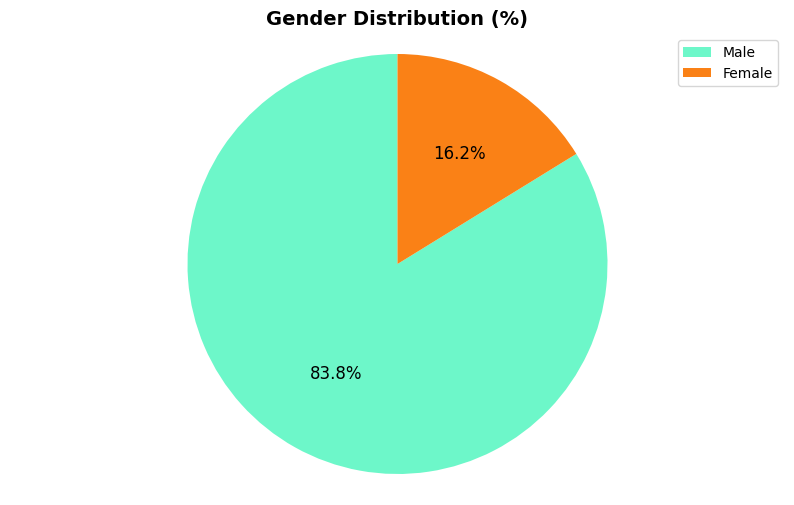

In [15]:
gender_counts = merged_df['Senior Citizen'].value_counts()
labels = gender_counts.index
sizes = gender_counts.values

# Plot pie chart
plt.figure(figsize=(10, 6))
plt.pie(sizes, autopct='%1.1f%%', startangle=90, colors=['#6df7c9','#fa8116'], textprops={'fontsize': 12})
plt.title('Gender Distribution (%)', fontsize=14, fontweight='bold')
plt.axis('equal')  # Keep circle shape
plt.legend(labels=['Male', 'Female'])
plt.show()

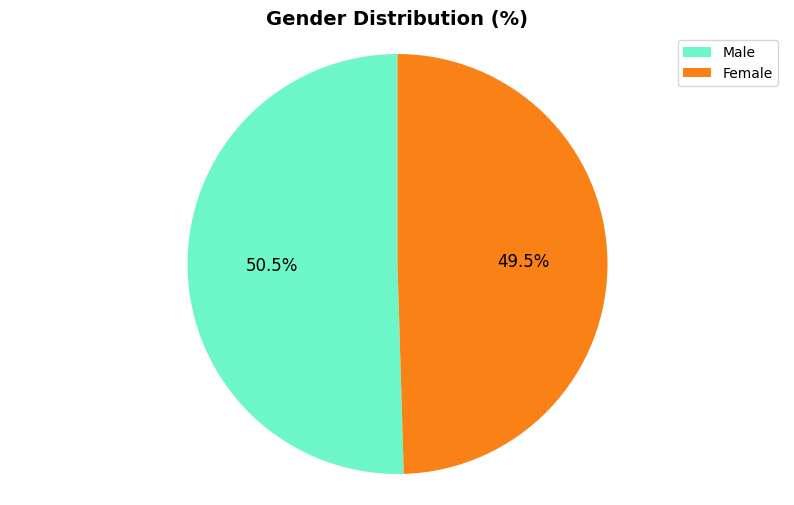

In [16]:
gender_counts = merged_df['Gender'].value_counts()
labels = gender_counts.index
sizes = gender_counts.values

# Plot pie chart
plt.figure(figsize=(10, 6))
plt.pie(sizes, autopct='%1.1f%%', startangle=90, colors=['#6df7c9','#fa8116'], textprops={'fontsize': 12})
plt.title('Gender Distribution (%)', fontsize=14, fontweight='bold')
plt.axis('equal')  # Keep circle shape
plt.legend(labels=['Male', 'Female'])
plt.show()